In [1]:
import matplotlib as plt
from rotations import rot_z
from helpers import load_dataloader, predict, rotate_image, optimize_latents_of_image, lerp, get_newest_model
from reni.utils.utils import find_nerfstudio_project_root
from reni.utils.colourspace import linear_to_sRGB

import os
from pathlib import Path
from helpers import models
from veni.utils.helpers import load_model, device
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib import gridspec
from PIL import Image
import numpy as np
import statistics
import pickle

project_root = find_nerfstudio_project_root(Path(os.getcwd()))
os.chdir(project_root)

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{extpfeil}",
    "font.family": "serif",
})

In [2]:
dataloader_mode = "test"
test_dataloader, metadata, num_train_data, num_eval_data = load_dataloader(dataloader_mode)
H, W = metadata["image_height"], metadata["image_width"]    


Setting up training dataset...

Caching all 3346 images.

Warning: If you run out of memory, try reducing the number of images to sample from.

Output()

Warning: Some cameras are equirectangular, but using default pixel sampler.

Setting up evaluation dataset...

Caching all 21 images.

Output()

Warning: Some cameras are equirectangular, but using default pixel sampler.

# Rotation animation

In [3]:
import torch
import torch.nn.functional as F

def rotate_image(img, angle):
    H, W, C = img.shape
    shift_px = (angle/360)*W
    img = img.permute(2, 0, 1).unsqueeze(0)  # (1, C, H, W)

    # Normalized horizontal shift: 1.0 corresponds to full width
    shift_norm = shift_px / W

    # Create base sampling grid
    xs = torch.linspace(-1, 1, W)
    ys = torch.linspace(-1, 1, H)
    grid_y, grid_x = torch.meshgrid(ys, xs, indexing="ij")

    # Apply normalized horizontal translation
    grid_x = grid_x + 2 * shift_norm  # because grid runs from -1 to 1

    # Wrap-around: cyclic longitude
    grid_x = (grid_x + 1) % 2 - 1

    grid = torch.stack((grid_x, grid_y), dim=-1).unsqueeze(0)

    # Bilinear sampling
    rotated = F.grid_sample(
        img, grid,
        mode="bilinear",
        padding_mode="border",
        align_corners=False
    )

    return rotated.squeeze(0).permute(1, 2, 0)

using VENI
ENCODER_PARAMETERS 21095624


/proj/ciptmp/ym26efer/ns5/lib/python3.11/site-packages/torch/nn/functional.py:4296: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
/proj/ciptmp/ym26efer/ns5/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(
/proj/ciptmp/ym26efer/ns5/lib/python3.11/site-packages/torch/nn/functional.py:4296: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
/proj/ciptmp/ym26efer/ns5/lib/python3.11/site-packages

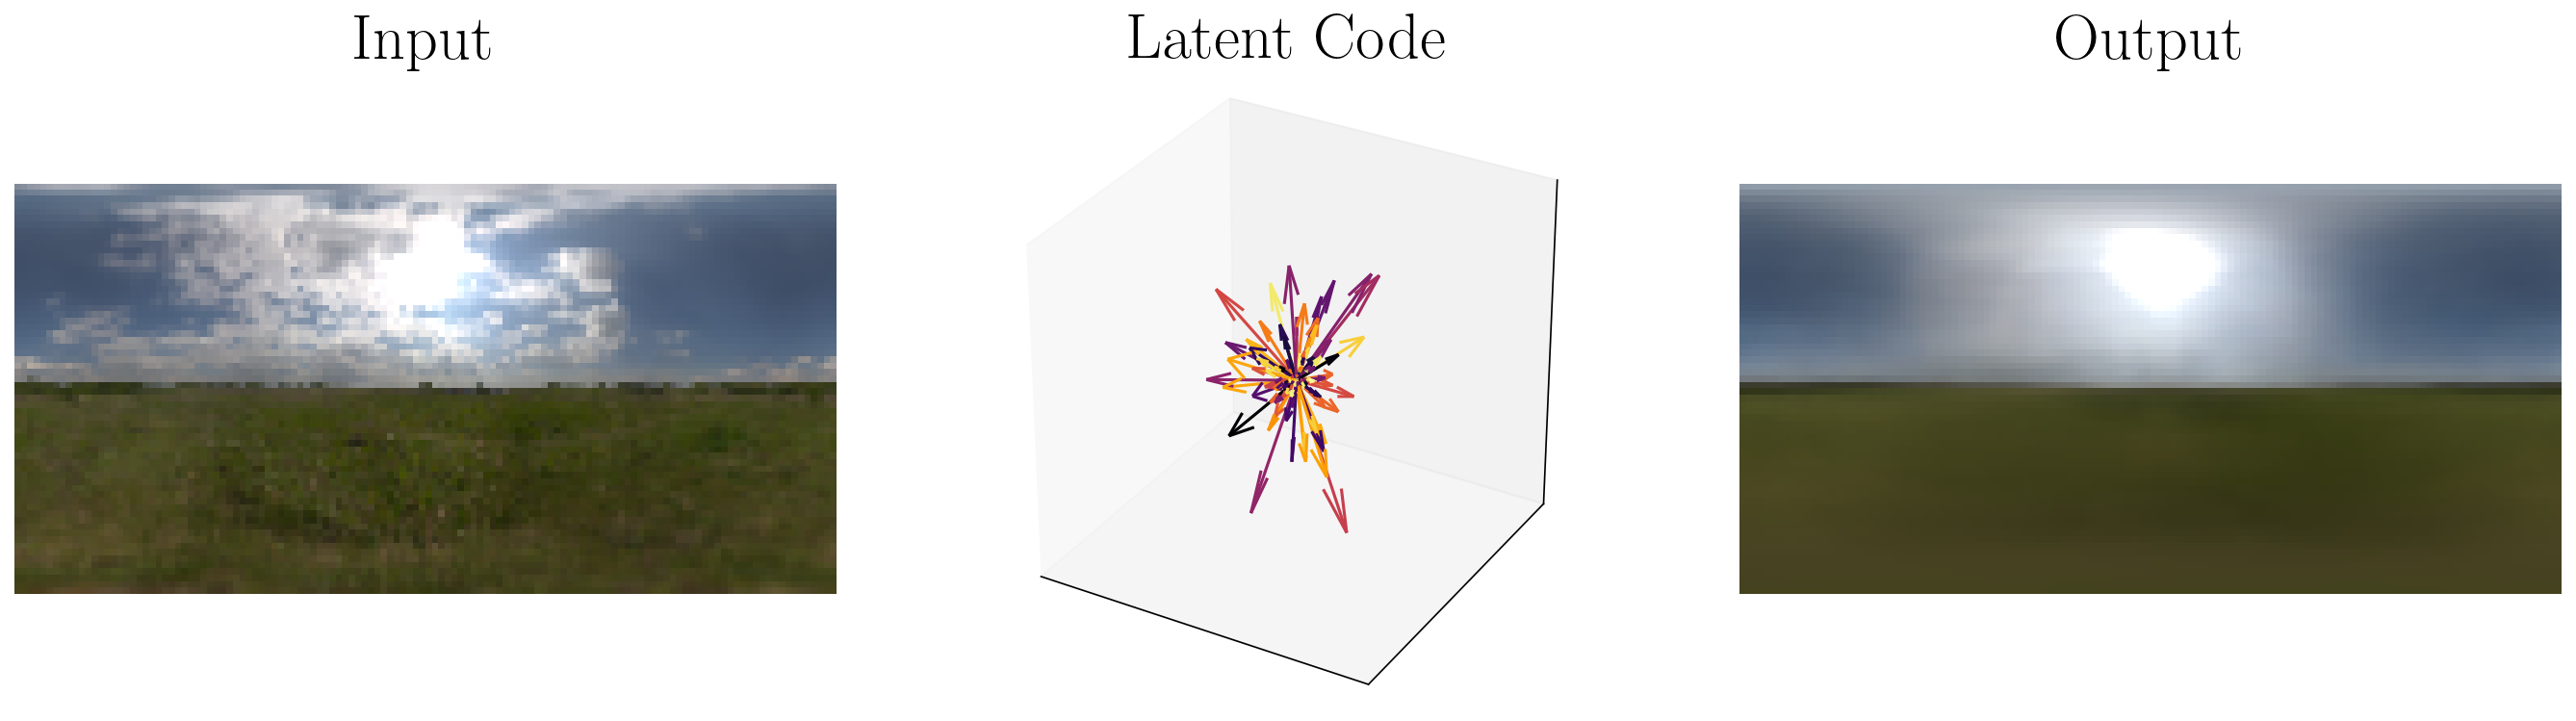

In [4]:
import pyexr
import cv2
from helpers import get_newest_model
import matplotlib.animation as animation 
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

test_dataloader.count = 0
camera, batch = next(test_dataloader)
output = []
num_eval = len(test_dataloader)

def animate_rotation(
            environment_map = Path("data/RENI_HDR/train/00122.exr"), 
            model_path = Path("outputs/veni/veni_300"),
            frames = 720, fps=30, savename="rotation",
            titles=False):
    environment_map = pyexr.read(str(environment_map.absolute())).astype("float32")
    environment_map[environment_map == np.inf] = np.nanmax(environment_map[environment_map != np.inf])
    # make any values less than zero equal to min non negative
    if np.any(environment_map>0):
        environment_map[environment_map <= 0] = np.nanmin(environment_map[environment_map > 0])
    
    environment_map = cv2.resize(environment_map, (128,64), interpolation=cv2.INTER_LINEAR)
    environment_map = torch.tensor(environment_map).float()[...,:3]
    environment_map = torch.log(environment_map+1e-8)
    
    
    model, pipeline_config = load_model(Path(model_path), model_only=True, metadata=metadata, model_type="VENI")
    
    image = rotate_image(environment_map,0)
    latents,pred,_,_ = predict(camera, model, batch={"image": image}, latents=None)
    
    image = torch.exp(image)
    image = linear_to_sRGB(image, use_quantile=True)
    pred = torch.exp(pred["rgb"])
    pred = linear_to_sRGB(pred, use_quantile=True).squeeze(0).cpu()
    
    
    fig = plt.figure(figsize=(18,5), dpi=150)
    fig.subplots_adjust(left=0.01, bottom=0, right=0.99, wspace=None, hspace=None)
    gs0 = gridspec.GridSpec(1,3, figure=fig, wspace=0.05, hspace=0.05)

    if titles:
        ax = fig.add_subplot(gs0[0])
        ax.set_yticks([])
        ax.set_xticks([])
        ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)   
        ax.set_title("Input", fontsize=32)
        ax = fig.add_subplot(gs0[1])
        ax.set_yticks([])
        ax.set_xticks([])
        ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)   
        ax.set_title("Latent Code", fontsize=32)
        ax = fig.add_subplot(gs0[2])
        ax.set_yticks([])
        ax.set_xticks([])
        ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)   
        ax.set_title("Output", fontsize=32)


    
    ax = fig.add_subplot(gs0[0])
    im=ax.imshow(image,interpolation='none')
    ax.set_yticks([])
    ax.set_xticks([])
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)


    
    latents = latents.cpu().squeeze(0)
    origins = torch.zeros_like(latents).cpu()
    ax = fig.add_subplot(gs0[1], projection='3d')
    torch.manual_seed(42)
    color_indices = torch.rand(latents.shape[0])
    colormap = cm.inferno
    global vec
    vec = ax.quiver(
        origins[:, 0], origins[:, 1], origins[:, 2],
        latents[:, 0], -latents[:, 1], latents[:, 2], color=colormap(color_indices),
    )
    qax = ax
    lim = torch.max(latents.norm(dim=-1)).cpu()
    ax.set_xlim([-lim, lim])
    ax.set_ylim([-lim, lim])
    ax.set_zlim([-lim, lim])
    ax.set_box_aspect([1, 1, 1])  # equal aspect ratio
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_zlabel('')   


    
    ax = fig.add_subplot(gs0[2])
    pr=ax.imshow(pred,interpolation='none')
    ax.set_yticks([])
    ax.set_xticks([])
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)    
    

    
    # initialization function: plot the background of each frame
    
    # animation function.  This is called sequentially
    def animate(i):
        global vec
        angle = i*(360/frames)
        image = rotate_image(environment_map,angle)
        latents,pred,_,_ = predict(camera, model, batch={"image": image}, latents=None)
        image = torch.exp(image)
        image = linear_to_sRGB(image, use_quantile=True)
        pred = torch.exp(pred["rgb"])
        pred = linear_to_sRGB(pred, use_quantile=True).squeeze(0).cpu()
        latents = latents.squeeze(0).cpu()
    
        im.set_data(image)
        pr.set_data(pred)
    
        vec.remove()
        vec = qax.quiver(
            origins[:, 0], origins[:, 1], origins[:, 2],
            latents[:, 0], -latents[:, 1], latents[:, 2], color=colormap(color_indices),
        )

        
        return [im, pr, vec]
    
    
    # calling the animation function     
    anim = animation.FuncAnimation(fig, animate, frames = frames, interval = 1) 
     
    # saves the animation in our desktop
    anim.save(f'publication/figures/{savename}.mp4', writer = 'ffmpeg', fps = fps)


#animate_rotation(model_path = Path("outputs/veni/veni_300"),frames = 720, fps=30, savename="rot_300_slow")
#animate_rotation(model_path = Path("outputs/veni/veni_300"),frames = 64, fps=10, savename="rot_300_fast")

#animate_rotation(model_path = Path("outputs/veni/veni_147"),frames = 720, fps=30, savename="rot_147_slow")
#animate_rotation(model_path = Path("outputs/veni/veni_147"),frames = 64, fps=10, savename="rot_147_fast")

#animate_rotation(model_path = Path("outputs/veni/veni_27"),frames = 720, fps=30, savename="rot_27_slow")
#animate_rotation(model_path = Path("outputs/veni/veni_27"),frames = 64, fps=10, savename="rot_27_fast")

#animate_rotation(environment_map = Path("data/RENI_HDR/test/00001.exr"),model_path = Path("outputs/veni/veni_300"),frames = 720, fps=30, savename="rot_300_slow_test")
#animate_rotation(environment_map = Path("data/RENI_HDR/test/00001.exr"),model_path = Path("outputs/veni/veni_300"),frames = 64, fps=10, savename="rot_300_fast_test")

animate_rotation(environment_map = Path("data/RENI_HDR/train/00122.exr"),model_path = Path("outputs/veni/veni_300"),frames = 64, fps=10, savename="suppl_rotation", titles=True)


using VENI
ENCODER_PARAMETERS 21095624


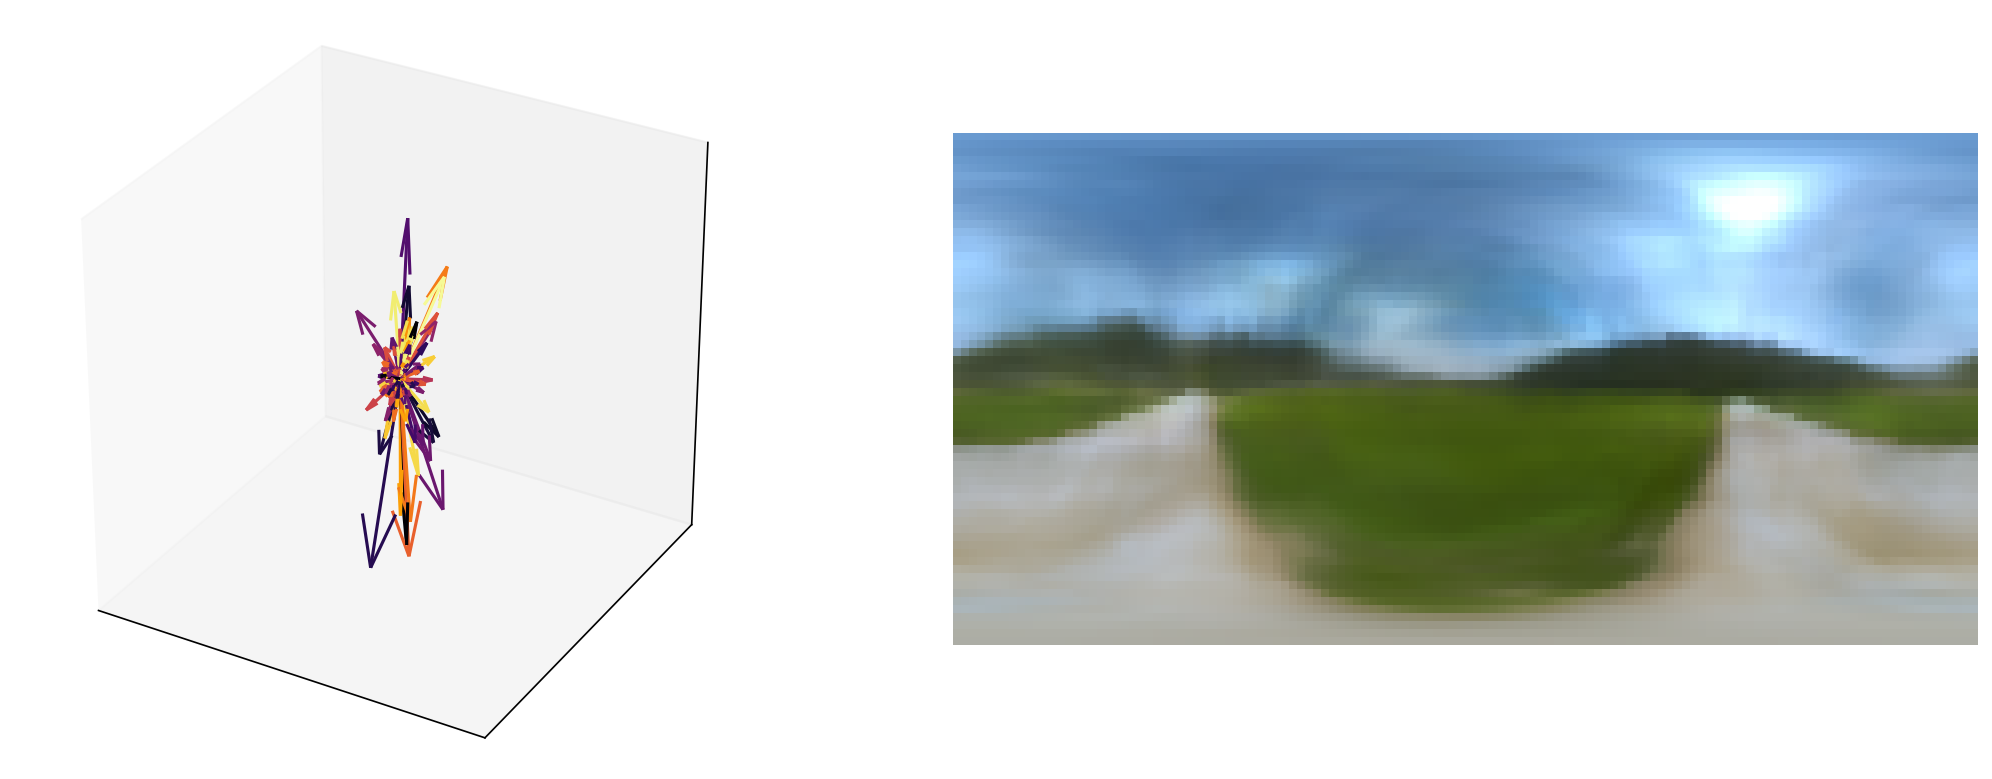

using VENI
ENCODER_PARAMETERS 21095624


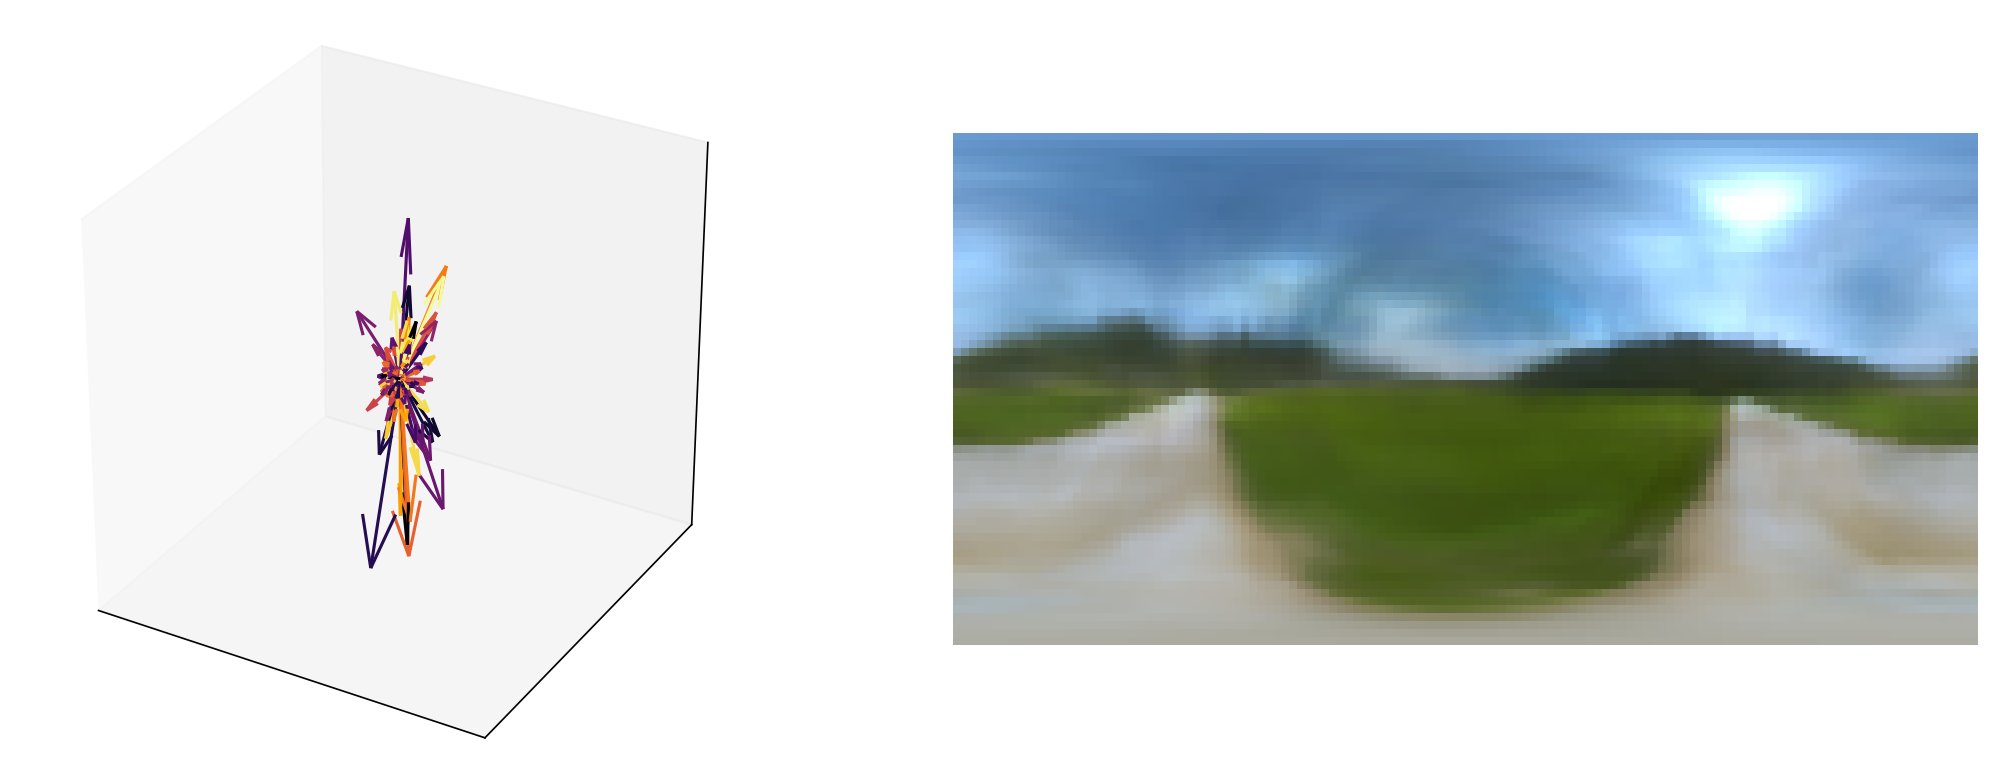

In [5]:
with open(f'publication/optimized_latents.pkl', 'rb') as file:
    optimized_latents = pickle.load(file)

def animate_rotation(
            model_path = Path("outputs/veni/veni_300"),
            model_name="Our Model 100",
            frames = 720, fps=30, savename="rotation", image_index = 0):

    model, pipeline_config = load_model(Path(model_path), model_only=True, metadata=metadata, model_type="VENI")
    latents = optimized_latents[model_name][image_index].unsqueeze(0)
    #latents = torch.rand(1,100,3, device=device)

    _,pred,_,_ = predict(camera, model, batch=None, latents=latents)
    
    pred = torch.exp(pred["rgb"])
    pred = linear_to_sRGB(pred, use_quantile=True).squeeze(0).cpu()
    
    
    fig = plt.figure(figsize=(14,5), dpi=150)
    fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=None, hspace=None)

    gs0 = gridspec.GridSpec(1,2, figure=fig, wspace=0.05, hspace=0.05)
        
    latents_rot = latents.cpu().squeeze(0)
    origins = torch.zeros_like(latents_rot).cpu()
    ax = fig.add_subplot(gs0[0], projection='3d')
    torch.manual_seed(42)
    color_indices = torch.rand(latents_rot.shape[0])
    colormap = cm.inferno
    global vec
    vec = ax.quiver(
        origins[:, 0], origins[:, 1], origins[:, 2],
        latents_rot[:, 0], latents_rot[:, 1], latents_rot[:, 2], color=colormap(color_indices),
    )
    qax = ax
    lim = torch.max(latents.norm(dim=-1)).cpu()
    ax.set_xlim([-lim, lim])
    ax.set_ylim([-lim, lim])
    ax.set_zlim([-lim, lim])
    ax.set_box_aspect([1, 1, 1])  # equal aspect ratio
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_zlabel('')
    
    
    ax = fig.add_subplot(gs0[1])
    pr=ax.imshow(pred,interpolation='none')
    ax.set_yticks([])
    ax.set_xticks([])
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)
    
    # animation function.  This is called sequentially
    def animate(i):
        global vec
        angle = i*(360/frames)
        rot_latents = latents@rot_z(torch.tensor(angle), degrees=True).to(device)
        _,pred,_,_ = predict(camera, model, batch=None, latents=rot_latents)
        pred = torch.exp(pred["rgb"])
        pred = linear_to_sRGB(pred, use_quantile=True).squeeze(0).cpu()
        rot_latents = rot_latents.squeeze(0).cpu()
    
        pr.set_data(pred)
    
        vec.remove()
        vec = qax.quiver(
            origins[:, 0], origins[:, 1], origins[:, 2],
            rot_latents[:, 0], rot_latents[:, 1], rot_latents[:, 2], color=colormap(color_indices),
        )
        
        return [pr, vec]
    
    
    # calling the animation function     
    anim = animation.FuncAnimation(fig, animate, frames = frames, interval = 1) 
     
    # saves the animation in our desktop
    anim.save(f'publication/figures/{savename}.mp4', writer = 'ffmpeg', fps = fps)
    plt.show()


animate_rotation(image_index = 0, model_path = Path("outputs/veni/veni_300"), model_name="Our Model 100",frames = 720, fps=30, savename="rot_single_300")
animate_rotation(image_index = 0, model_path = Path("outputs/veni/veni_300"), model_name="Our Model 100",frames = 192, fps=30, savename="rot_single_300_fast")


# Interpolation

using VENI
ENCODER_PARAMETERS 21095624


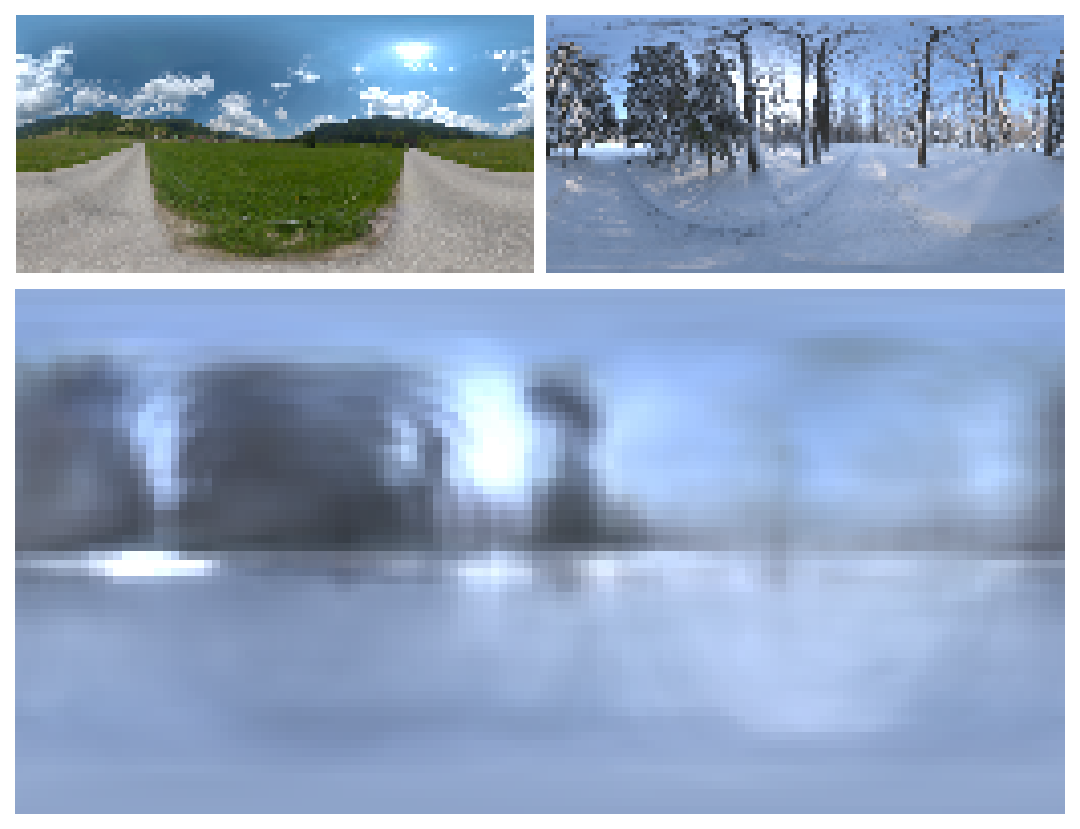

using Reni++


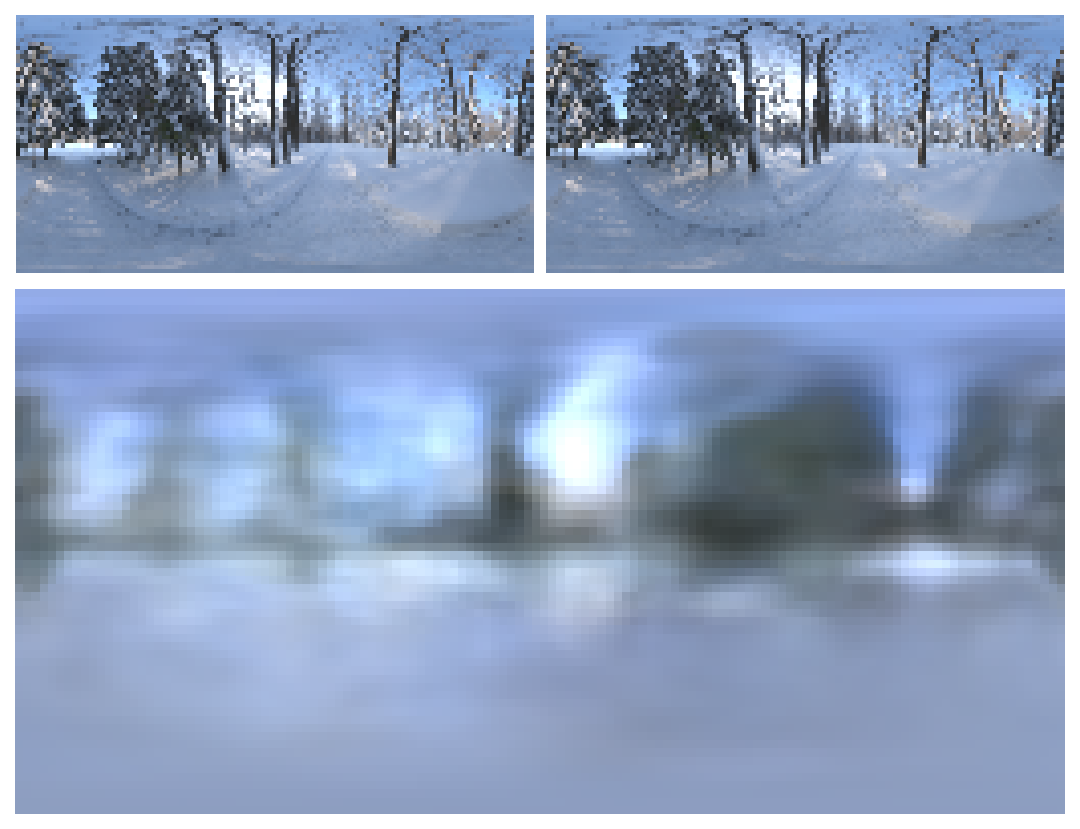

using VENI
ENCODER_PARAMETERS 20629522


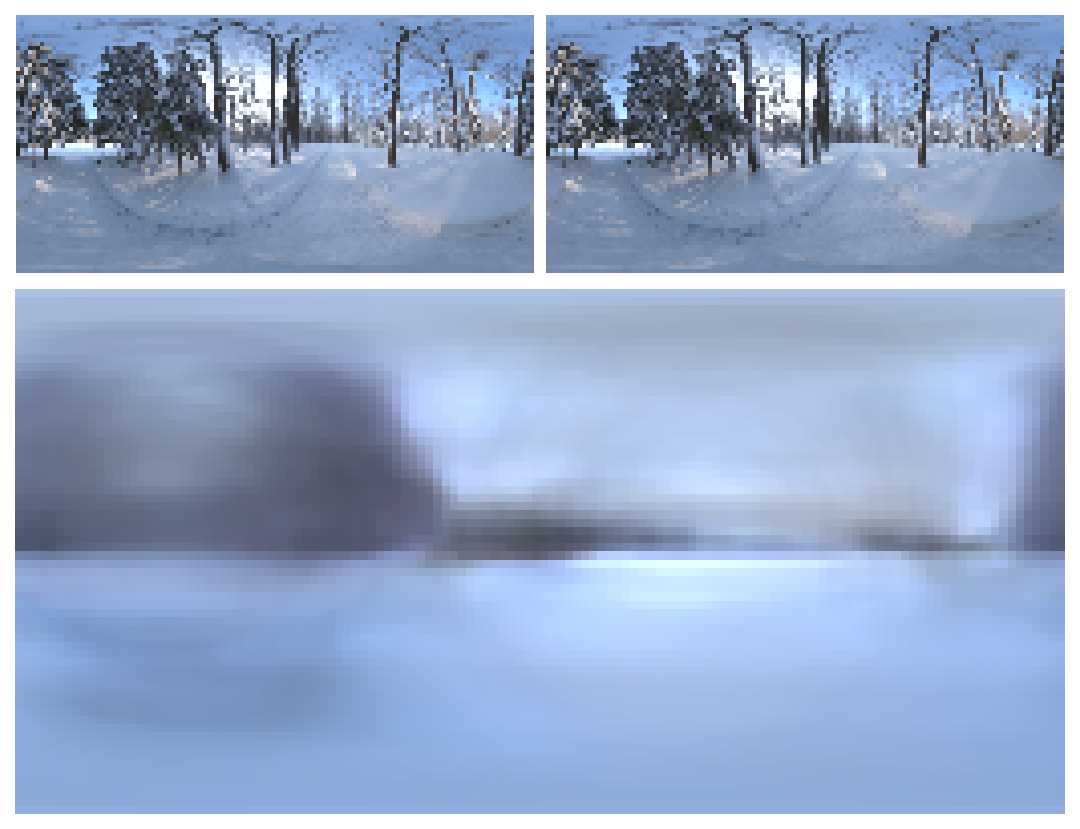

using Reni++


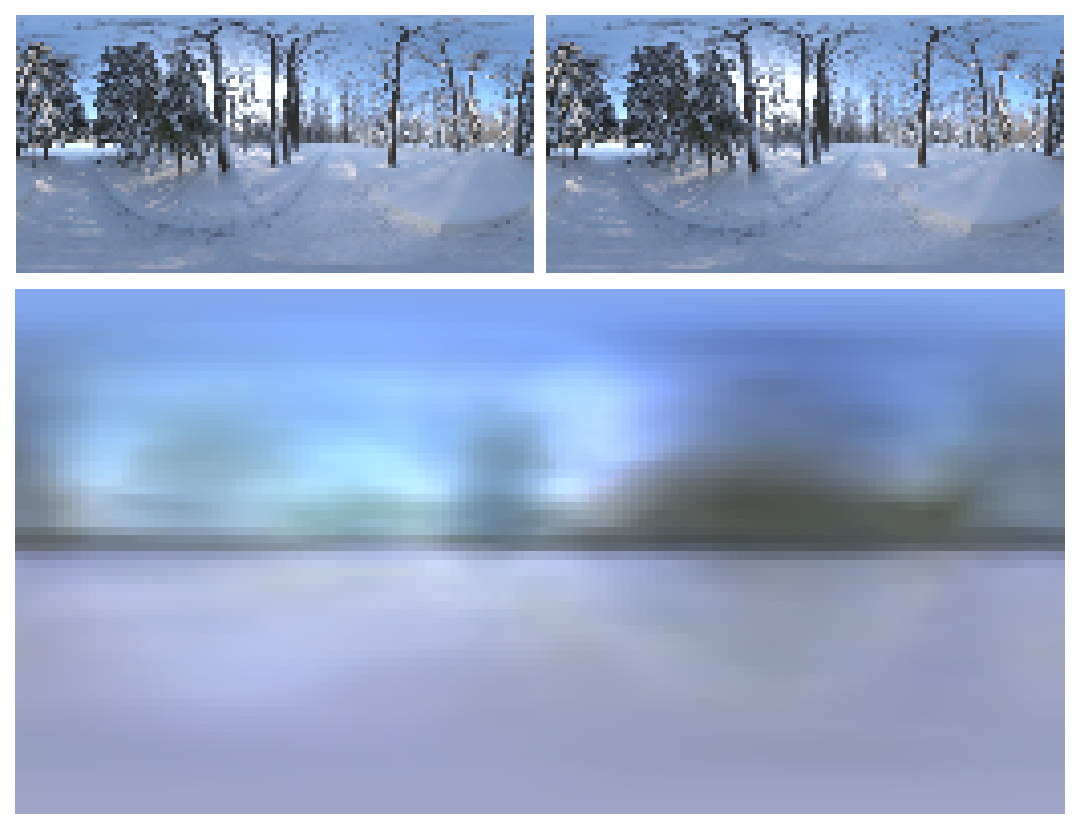

In [6]:
def animate_interpolation(
            model_path = Path("outputs/veni/veni_300"),
            model_name="Our Model 100",
            savename = "interpolation",
            frames = 720, img_idxs= [0,1,2,3,4,5]):
    
    fig = plt.figure(figsize=(7,5.35), dpi=150)
    fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=None, hspace=None)

    gs0 = gridspec.GridSpec(3,2, figure=fig, wspace=0.02, hspace=0.05, height_ratios=[1,1,1])

    if "RENI++" in model_name:
        model, pipeline_config = load_model(
            Path(model_path), 
            model_only=True, 
            metadata=metadata, 
            model_type="RENI", 
            num_train_data=num_train_data, 
            num_eval_data=num_eval_data
        )
        optimized_latents = {model_name: model.field.eval_mu}
    else:
        model, pipeline_config = load_model(Path(model_path), model_only=True, metadata=metadata, model_type="VENI")
        with open(f'publication/optimized_latents.pkl', 'rb') as file:
            optimized_latents = pickle.load(file)
    

    img_idxs += [img_idxs[0]]
    
    test_dataloader.count = img_idxs[0]
    camera, batch = next(test_dataloader)
    img = torch.exp(batch["image"])
    img = linear_to_sRGB(img, use_quantile=True).squeeze(0).cpu()
    ax = fig.add_subplot(gs0[0,0])
    left=ax.imshow(img,interpolation='none')
    ax.set_yticks([])
    ax.set_xticks([])
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

    latents = optimized_latents[model_name][img_idxs[0]].unsqueeze(0)
    _,pred,_,_ = predict(camera, model, batch=None, latents=latents)
    pred = torch.exp(pred["rgb"])
    pred = pred.reshape(H,W,3)
    pred = linear_to_sRGB(pred, use_quantile=True).cpu()
    ax = fig.add_subplot(gs0[1:3,0:3])
    center=ax.imshow(pred,interpolation='none')
    ax.set_yticks([])
    ax.set_xticks([])
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)   

    
    test_dataloader.count = img_idxs[1]
    camera, batch = next(test_dataloader)
    img = torch.exp(batch["image"])
    img = linear_to_sRGB(img, use_quantile=True).squeeze(0).cpu()
    ax = fig.add_subplot(gs0[0,1])
    right=ax.imshow(img,interpolation='none')
    ax.set_yticks([])
    ax.set_xticks([])
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)   

    def animate(i):
        start_idx = int(i/(frames/(len(img_idxs)-1)))
        end_idx = int(i/(frames/(len(img_idxs)-1)))+1
        t = i/(frames/(len(img_idxs)-1))-start_idx

        test_dataloader.count = img_idxs[start_idx]
        camera, batch = next(test_dataloader)
        img = torch.exp(batch["image"])
        img = linear_to_sRGB(img, use_quantile=True).squeeze(0).cpu()
        left.set_data(img)
        
        start = optimized_latents[model_name][img_idxs[start_idx]].unsqueeze(0)
        end = optimized_latents[model_name][img_idxs[end_idx]].unsqueeze(0)
        _,pred,_,_ = predict(camera, model, batch=None, latents=lerp(start, end, t))
        pred = torch.exp(pred["rgb"])
        pred = pred.reshape(H,W,3)
        pred = linear_to_sRGB(pred, use_quantile=True).cpu()
        center.set_data(pred)

        test_dataloader.count = img_idxs[end_idx]
        camera, batch = next(test_dataloader)
        img = torch.exp(batch["image"])
        img = linear_to_sRGB(img, use_quantile=True).squeeze(0).cpu()
        right.set_data(img)
    
        return [center, left, right]
    
    
    # calling the animation function     
    anim = animation.FuncAnimation(fig, animate, frames = frames, interval = 1) 
     
    # saves the animation in our desktop
    anim.save(f'publication/figures/{savename}.mp4', writer = 'ffmpeg', fps = 30)
    plt.show()

img_idxs = [19,13, 9, 7, 2,0]
animate_interpolation(img_idxs = img_idxs, savename="interpolation_ours_300")
animate_interpolation(img_idxs = img_idxs, model_path = "outputs/reni/reni_plus_plus_models/latent_dim_100/" ,model_name="RENI++ 100", savename="interpolation_reni_300")
animate_interpolation(img_idxs = img_idxs,model_path = Path("outputs/veni/veni_27"), model_name="Our Model 9", savename="interpolation_ours_27")
animate_interpolation(img_idxs = img_idxs, model_path = "outputs/reni/reni_plus_plus_models/latent_dim_9/" ,model_name="RENI++ 100", savename="interpolation_reni_27")


# Uniqueness

using Reni++
using VENI
ENCODER_PARAMETERS 21095624


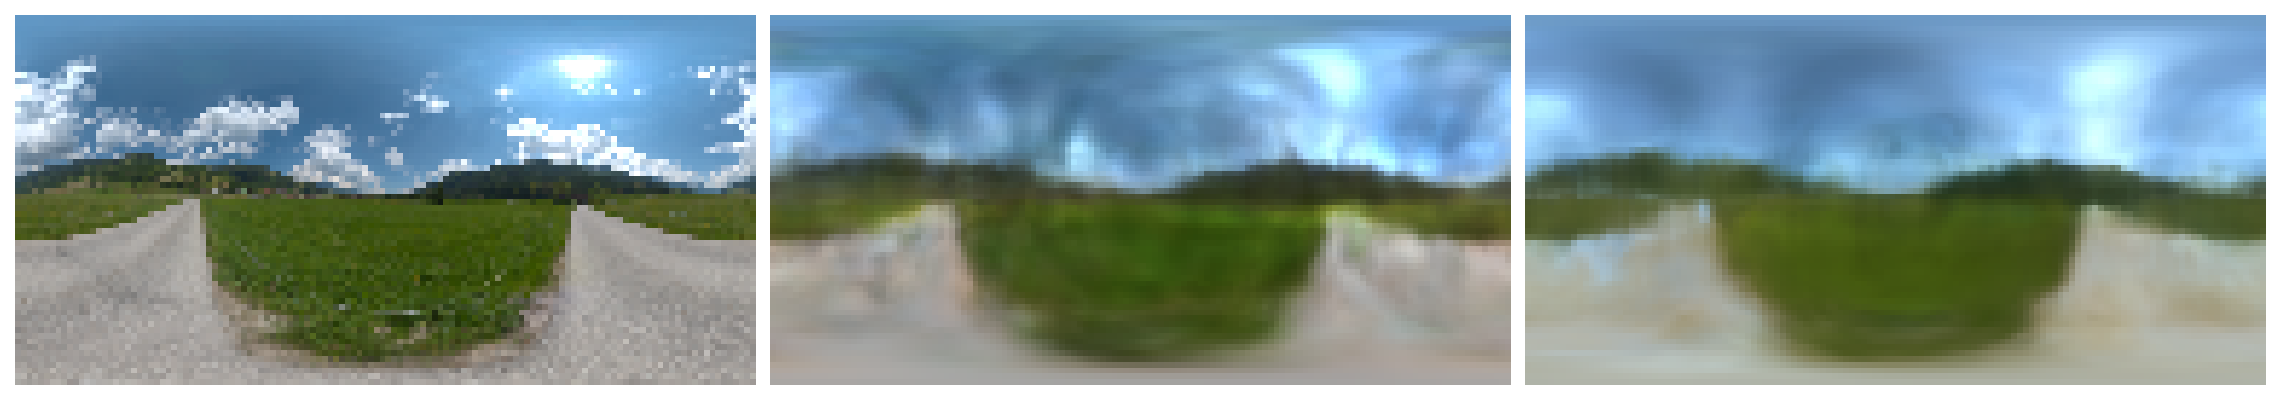

using Reni++
using VENI
ENCODER_PARAMETERS 20629522


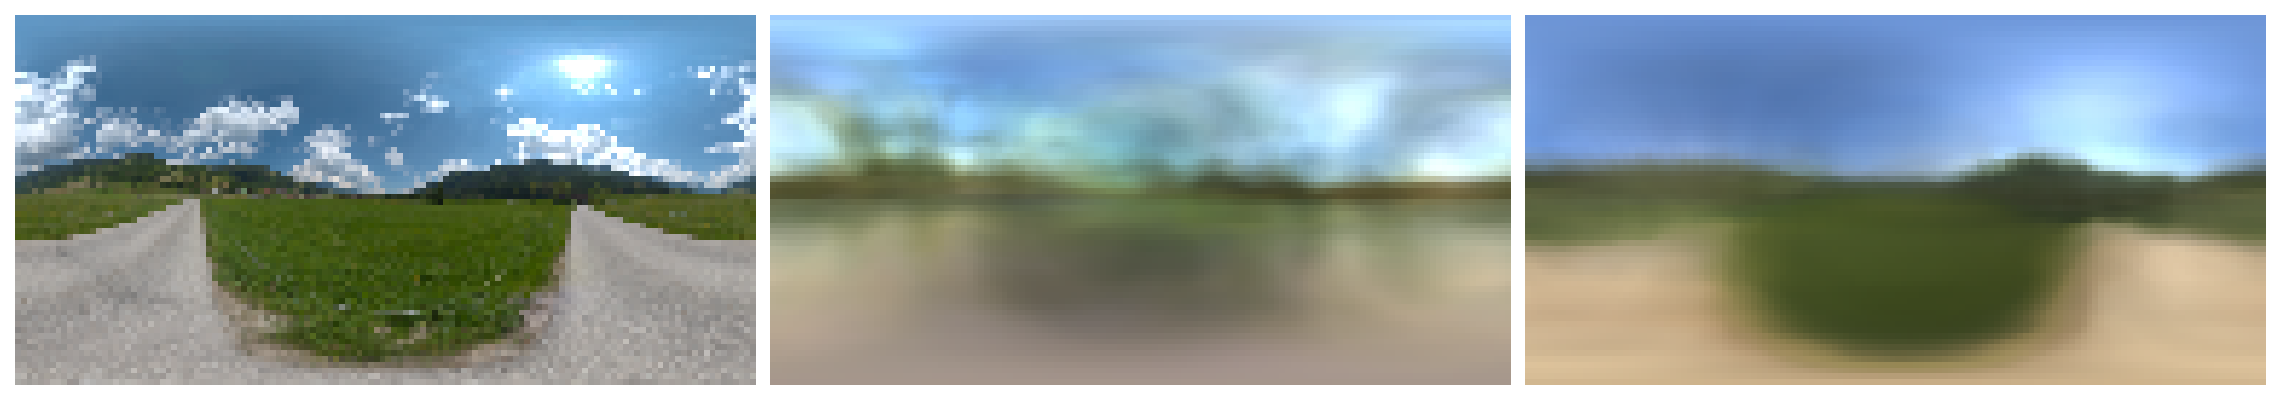

using Reni++
using VENI
ENCODER_PARAMETERS 20834402


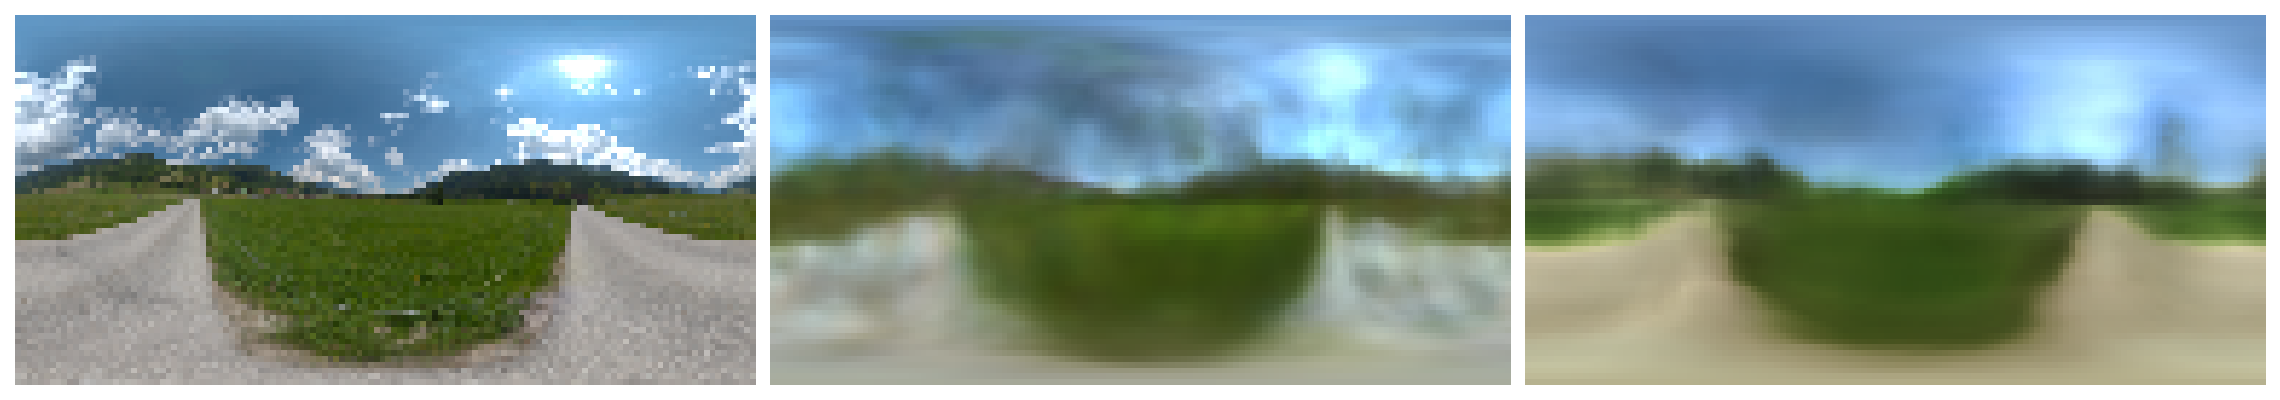

In [7]:
def animate_uniqueness(
            optimized_latents_uniqueness,        
            model_path_ours = Path("outputs/veni/veni_300"),
            model_path_reni = "outputs/reni/reni_plus_plus_models/latent_dim_100/",
            savename = "uniqueness",
            frames = 720):
    
    fig = plt.figure(figsize=(15,3), dpi=150)
    fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=None, hspace=None)
    gs0 = gridspec.GridSpec(1,3, figure=fig, wspace=0.02, hspace=0.05)

    reni, pipeline_config = load_model(
        Path(model_path_reni), 
        model_only=True, 
        metadata=metadata, 
        model_type="RENI", 
        num_train_data=num_train_data, 
        num_eval_data=num_eval_data
    )
    ours, pipeline_config = load_model(Path(model_path_ours), model_only=True, metadata=metadata, model_type="VENI")
    
    test_dataloader.count = 0
    camera, batch = next(test_dataloader)
    img = torch.exp(batch["image"])
    img = linear_to_sRGB(img, use_quantile=True).squeeze(0).cpu()
    ax = fig.add_subplot(gs0[0])
    GT=ax.imshow(img,interpolation='none')
    ax.set_yticks([])
    ax.set_xticks([])
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

    latents1, _ = optimized_latents_uniqueness["RENI++"]
    _,pred,_,_ = predict(camera, reni, batch=None, latents=latents1.to(device))
    pred = torch.exp(pred["rgb"])
    pred = pred.reshape(H,W,3)
    pred = linear_to_sRGB(pred, use_quantile=True).cpu()
    ax = fig.add_subplot(gs0[1])
    reni_img=ax.imshow(pred,interpolation='none')
    ax.set_yticks([])
    ax.set_xticks([])
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)   

    latents1, _ = optimized_latents_uniqueness["Ours"]
    _,pred,_,_ = predict(camera, ours, batch=None, latents=latents1.to(device))
    pred = torch.exp(pred["rgb"])
    pred = pred.reshape(H,W,3)
    pred = linear_to_sRGB(pred, use_quantile=True).cpu()
    ax = fig.add_subplot(gs0[2])
    ours_img=ax.imshow(pred,interpolation='none')
    ax.set_yticks([])
    ax.set_xticks([])
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)   
    
    def animate(i):        
        lookup = [*torch.linspace(0,1,int((frames-20)/2)),*[1]*10,*torch.linspace(1,0,int((frames-20)/2)),*[0]*10]
        t = lookup[i]
                
        latents1, latents2 = optimized_latents_uniqueness["Ours"]
        _,pred,_,_ = predict(camera, ours, batch=None, latents=lerp(latents1, latents2, t).to(device))
        pred = torch.exp(pred["rgb"])
        pred = pred.reshape(H,W,3)
        pred = linear_to_sRGB(pred, use_quantile=True).cpu()
        ours_img.set_data(pred)

        latents1, latents2 = optimized_latents_uniqueness["RENI++"]
        _,pred,_,_ = predict(camera, reni, batch=None, latents=lerp(latents1, latents2, t).to(device))
        pred = torch.exp(pred["rgb"])
        pred = pred.reshape(H,W,3)
        pred = linear_to_sRGB(pred, use_quantile=True).cpu()
        reni_img.set_data(pred)
        
        
        return [ours_img, reni_img]
    
    
    # calling the animation function     
    anim = animation.FuncAnimation(fig, animate, frames = frames, interval = 1) 
     
    # saves the animation in our desktop
    anim.save(f'publication/figures/{savename}.mp4', writer = 'ffmpeg', fps = 30)
    plt.show()

with open(f"publication/optimized_latents_uniqueness_teaser.pkl", 'rb') as file:
    optimized_latents_uniqueness = pickle.load(file)

animate_uniqueness(optimized_latents_uniqueness, frames = 120, savename="uniqueness_300")

with open(f'publication/uniqueness_optimization_full_17.pkl', 'rb') as file:
    uniqueness_optimization_full = pickle.load(file)

optimized_latents_uniqueness = { "Ours": uniqueness_optimization_full["Our Model 9"][0], "RENI++": uniqueness_optimization_full["RENI++ 9"][0]}

animate_uniqueness(optimized_latents_uniqueness, frames = 120, 
                   model_path_ours = Path("outputs/veni/veni_27"),
                   model_path_reni = "outputs/reni/reni_plus_plus_models/latent_dim_9/",
                   savename="uniqueness_27")

optimized_latents_uniqueness = { "Ours": uniqueness_optimization_full["Our Model 49"][0], "RENI++": uniqueness_optimization_full["RENI++ 49"][0]}

animate_uniqueness(optimized_latents_uniqueness, frames = 120, 
                   model_path_ours = Path("outputs/veni/veni_147"),
                   model_path_reni = "outputs/reni/reni_plus_plus_models/latent_dim_49/",
                   savename="uniqueness_147")
